In [1]:
!uv pip install shap xgboost scikit-learn

import shap
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from pathlib import Path

# Premium Plot Theme
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# Load ML Data
df = pd.read_parquet(Path("../data/processed/indian_songs_ml_ready.parquet"))
df['is_hit'] = (df['popularity'] >= 75).astype(int)

FEATURES = [col for col in df.columns if col not in ['popularity', 'is_hit']]
X = df[FEATURES]
y = df['is_hit']

# We need to quickly retrain the model in this notebook so SHAP can access it
# (In production, we'll load the saved .pkl file)
hit_ratio = (y == 0).sum() / (y == 1).sum()
xgb_clf = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, scale_pos_weight=hit_ratio, random_state=42, eval_metric='logloss')
xgb_clf.fit(X, y)

print("✅ Model Trained. Initializing SHAP...")

Using Python 3.12.7 environment at: /Users/manaskolaskar/Developer/Projects/spotify-india-intelligence/.venv
Checked 3 packages in 42ms
✅ Model Trained. Initializing SHAP...


✅ SHAP Values Calculated. Plotting Summary...


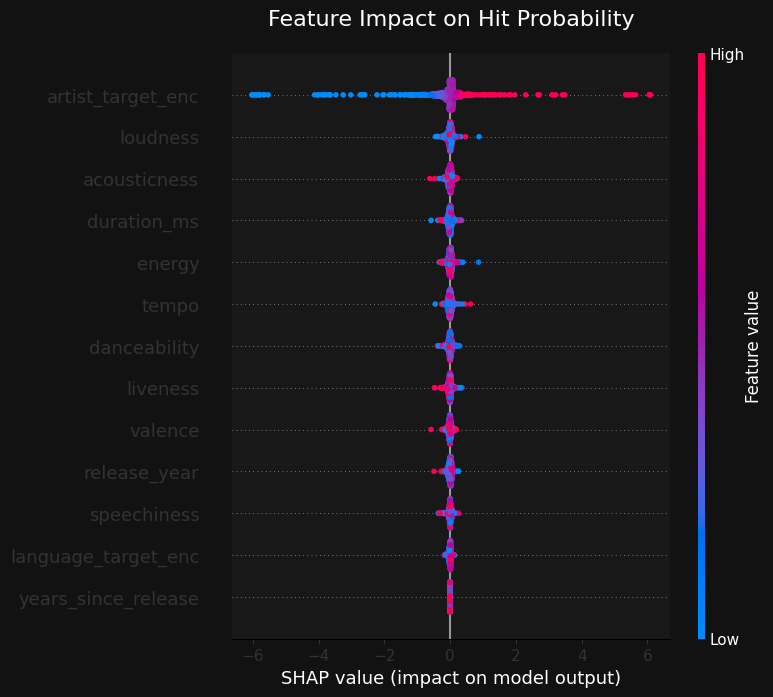

In [2]:
# SHAP TreeExplainer is highly optimized for XGBoost
explainer = shap.TreeExplainer(xgb_clf)

# Calculate SHAP values for a sample of the data (full dataset takes too long)
# Let's sample 1000 rows for speed
X_sample = X.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP Values Calculated. Plotting Summary...")

# Summary Plot: Shows feature importance AND direction of impact
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="dot", color='#1DB954', show=False)
plt.gca().set_facecolor('#181818')
plt.gcf().set_facecolor('#121212')
plt.title("Feature Impact on Hit Probability", fontsize=16, pad=20, color='white')
plt.show()

🎵 Audio Profile of Selected Song:
                            167
danceability           0.690000
energy                 0.959000
tempo                174.051000
language_target_enc   62.555774
artist_target_enc     90.000000


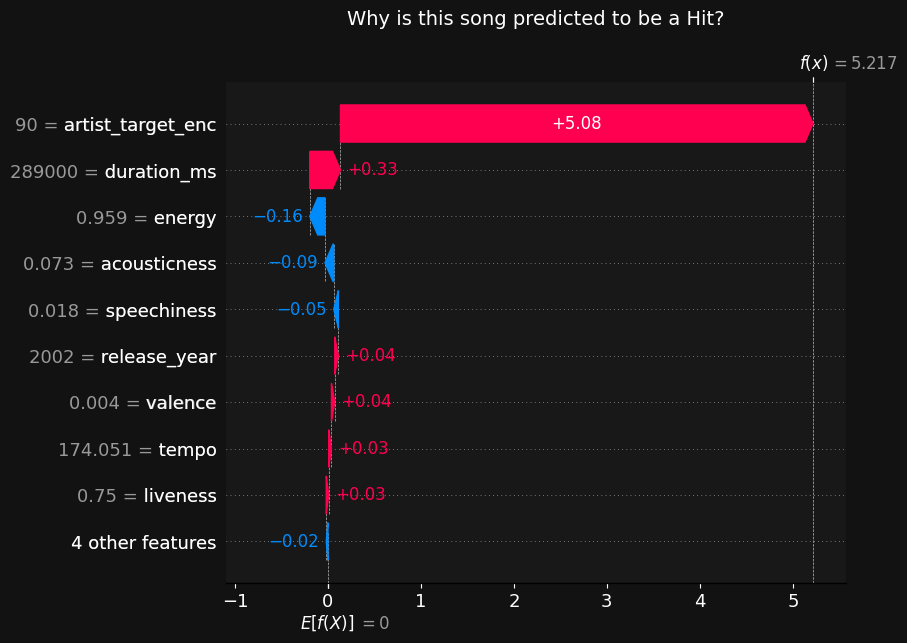

In [3]:
# Let's explain WHY a specific song is predicted to be a hit
# Pick a random song that is predicted to be a hit
hit_songs = X[X['artist_target_enc'] > 75].head(5) # Find songs with popular artists
single_song = hit_songs.iloc[[0]] # Take the first one

# Calculate SHAP for this one song
shap_values_single = explainer.shap_values(single_song)

# Waterfall Plot (The "Receipt" of the prediction)
print("🎵 Audio Profile of Selected Song:")
print(single_song[['danceability', 'energy', 'tempo', 'language_target_enc', 'artist_target_enc']].T)

plt.figure()
shap.waterfall_plot(shap.Explanation(values=shap_values_single[0], 
                                     base_values=explainer.expected_value, 
                                     data=single_song.iloc[0], 
                                     feature_names=FEATURES), show=False)
plt.gcf().set_facecolor('#121212')
plt.title("Why is this song predicted to be a Hit?", fontsize=14, pad=20, color='white')
plt.show()